# Data Manipulation

This notebook will only be used to create a processed version of the source file 'creditcard.csv' <br>
The new version of this file is named 'clean_creditcard.parquet' and will be used for further testing and training. The reason for changing the file format is to reduce the final file size and increase reading speed since the '.parquet' format is binary. To avoid data leakage, the resampling techniques (SMOTE) will be applied only to the training set after data splitting.

## Importing library

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow
import os

## Opening File

In [2]:
# Opening the CSV file and creating a dataframe
# CCDF stands for Credit Card Data Frame
CCDF = pd.read_csv('../data/raw/creditcard.csv')
CCDF.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Exploratory Data Analisys

In [3]:
# File dimensions (y, x)
CCDF.shape

(284807, 31)

In [4]:
# Column data type information
CCDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
# Class imbalance percentage
# Fraudulent transactions are labled as "1"
counts = CCDF.Class.value_counts()
percent = CCDF.Class.value_counts(normalize = True) * 100

summary = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percent})

print(summary)

        Count  Percentage (%)
Class                        
0      284315       99.827251
1         492        0.172749


The dataset is highly imbalanced, containing only 0.17% of fraudulent cases, wich implies the need for oversampling treatment to reduce false negative rate

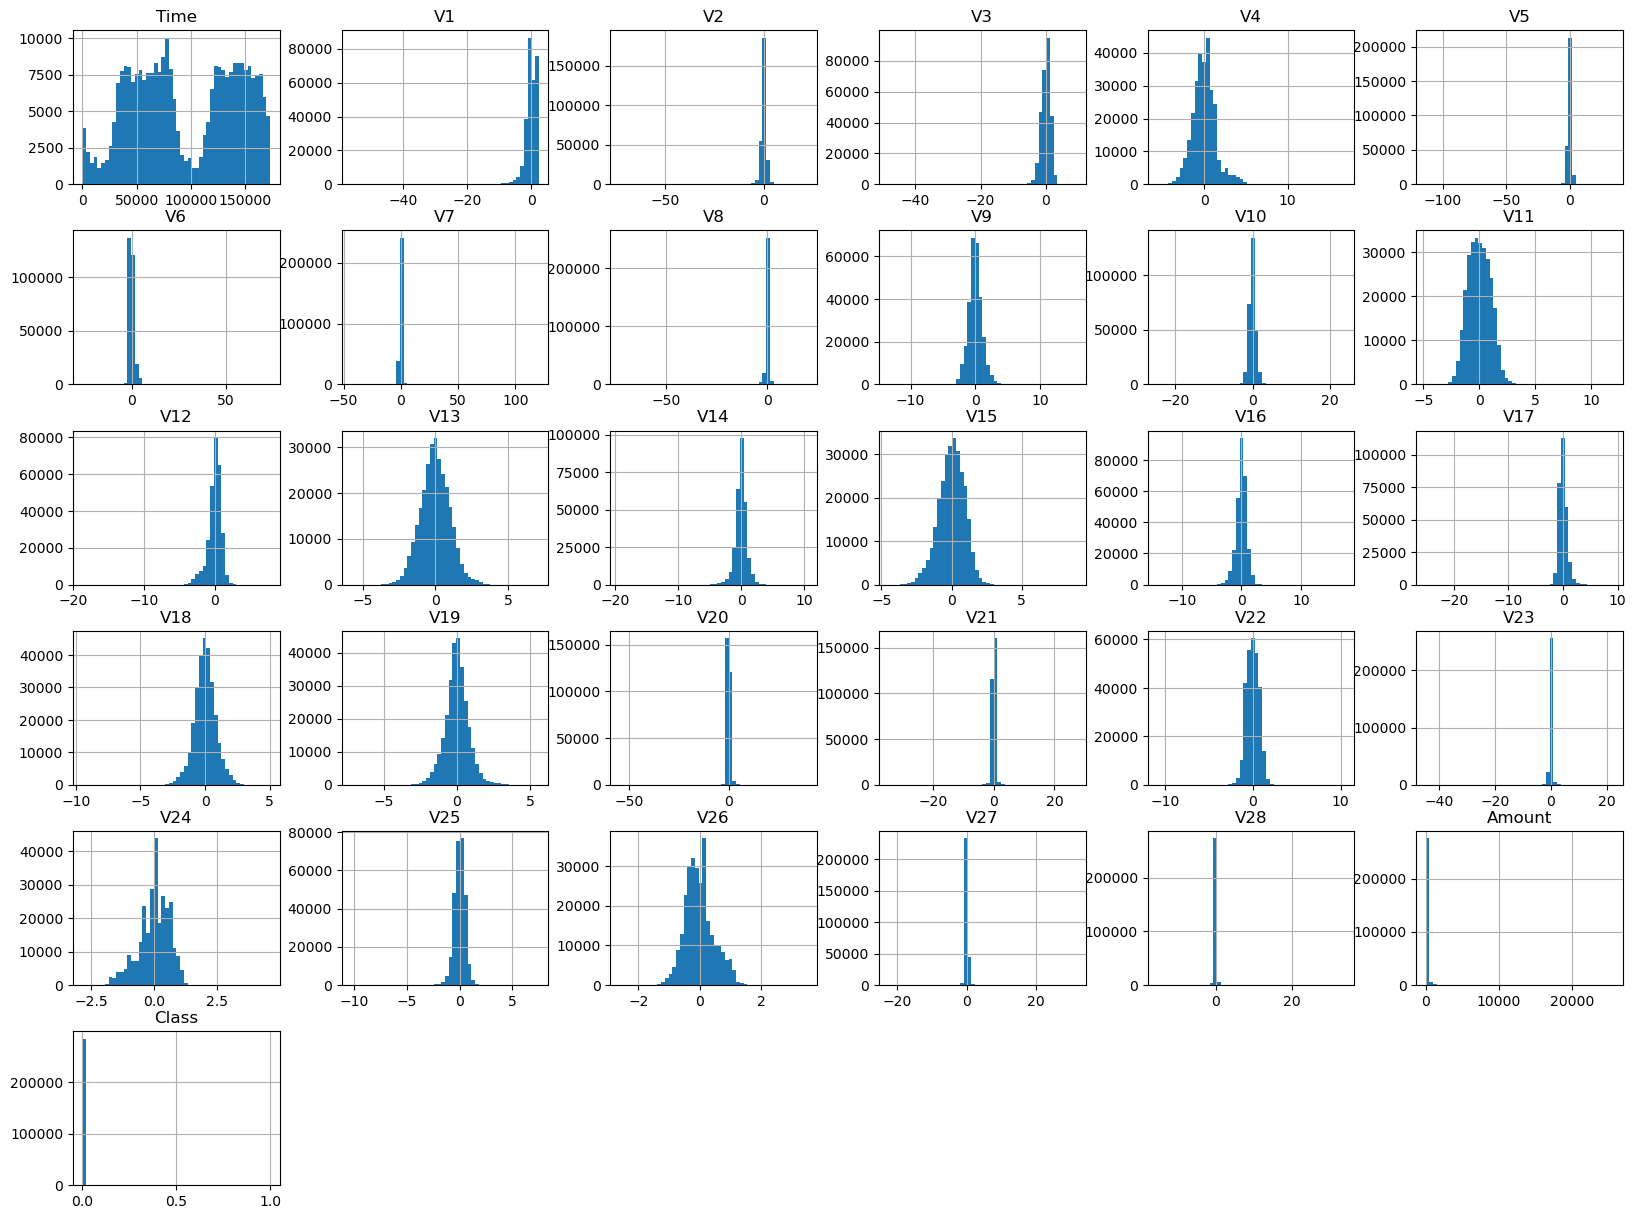

In [6]:
# Histograms Visualization - Feature distribution
CCDF.hist(bins=50, figsize=(20,15))
plt.show()

Outliers were not removed, as extreme values may correspond to fraudulent transactions and are therefore relevant for the analysis.

<Axes: >

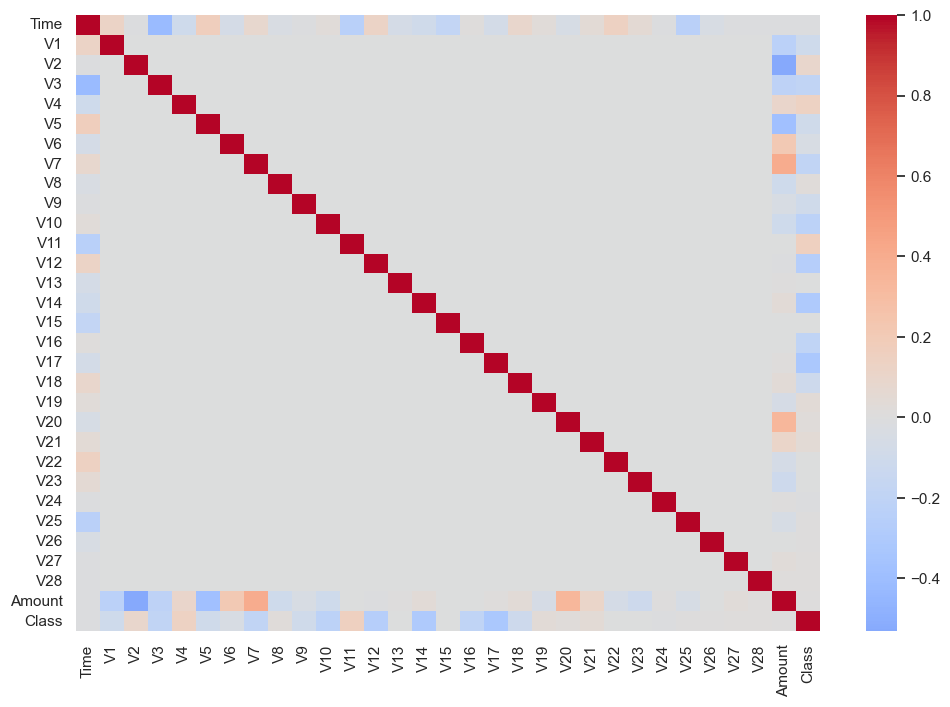

In [7]:
# Correlation between different variables
corr = CCDF.corr()

sns.set_theme(rc = {"figure.figsize":(12, 8)})
sns.heatmap(CCDF.corr(), cmap = 'coolwarm', center=0)

The variables listed from V1-V28 were transformed by Principal Component Analysis **(PCA)**, this results in a lower level of correlation between the values.

In [8]:
# Missing rows on each column
CCDF.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
# Counting duplicated lines
(f'Total duplicates: {CCDF.duplicated().sum()}')

'Total duplicates: 1081'

In [10]:
# Deleting duplicates to minimize error
CCDF.drop_duplicates(keep = 'first', inplace = True)
(f'Total duplicates after correction: {CCDF.duplicated().sum()}')

'Total duplicates after correction: 0'

Although null values were not found, duplicates within the dataset were identified and removed in order to improve model training.

## Saving Clean Dataset

In [11]:
# Verifying if there is a folder to save the processed file
if not os.path.exists('../data/processed'):
    os.makedirs('../data/processed')
    print('Folder created successfully')
else:
    print('Folder already exists')

Folder created successfully


In [12]:
# Saving the new spreadsheet as 'clean_creditcard.parquet' using compression zstandard level 22 to reduce its size
CCDF.to_parquet('../data/processed/clean_creditcard.parquet', engine = 'pyarrow', compression = 'zstd', compression_level = 22)
print('File compressed successfully')

File compressed successfully


## Summary of exploratory data analysis

1. The dataset is highly imbalanced most transactions are legitimate. <br>
2. Outliers were preserved due to their potential relevance in fraud detection<br>
3. Features are PCA-transformed, resulting in low correlation<br>
4. Duplicated values were removed<br>